# Gradient Boosting — Performance with Discipline (and Leakage Avoidance)

<hr>

<center>
<div>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/mgmt_474_ai_logo_02-modified.png" width="200"/>
</div>
</center>

# <center><a class="tocSkip"></center>
# <center>QM47400 Predictive Analytics</center>
# <center>Professor: Davi Moreira </center>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/blob/main/notebooks/nb13_gradient_boosting.ipynb)

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain how gradient boosting reduces **bias** by training trees sequentially on the residuals of the previous trees, on both classification and regression cases.
2. Fit `GradientBoostingClassifier` and `GradientBoostingRegressor`; demonstrate the CV-score lift over the random forest from nb12 and the **Week-2 reference**.
3. Diagnose the `learning_rate × n_estimators` trade-off — why "lots of trees, slow learning rate" beats "few trees, fast learning rate" at the same total fit budget.
4. Recognize and prevent **boosting's amplification of leaky features** — the failure mode that nb09's leakage case studies set up.

---


> **📋 Participation Reminder:** This notebook contains **2 PAUSE-AND-DO exercises** — one per case. Complete both before submitting your notebook.

---

## 💼 Why This Matters

Random forests reduce **variance** by averaging many trees. Gradient boosting reduces **bias** by stacking trees sequentially — each new tree fits the *residuals* (regression) or *misclassifications* (classification) of the running ensemble. The two strategies attack different parts of the bias/variance decomposition; combining their lessons in nb14's selection ceremony usually produces the strongest model on tabular data.

For the **State Health Department's** screening pipeline, the case for gradient boosting is the same as for the random forest — but with one extra ask: *"can we squeeze the last point of ROC-AUC out of the model?"* That last point matters when the false-negative cost is a missed cancer diagnosis. Boosting often delivers it.

For **HomeValue Analytics'** price-prediction model, the case is sharper. The random forest in nb12 already beat the OLS reference by \~20 R² points on California Housing; gradient boosting typically lifts that by another 3–5 points, which translates to \~USD 5–8K reduction in prediction RMSE — meaningful when the median home value being predicted is around USD 200K.

The cost is real: gradient boosting is sequential (cannot fully parallelize), more sensitive to hyperparameters than random forests, and prone to overfitting if you let it run too many iterations. Two of these risks have specific mitigations covered in this notebook: tune `learning_rate × n_estimators` together, and **never let gradient boosting see a leaky feature** — boosting will amplify the leak more aggressively than any other algorithm in this course.

> **A question that often comes up here:** *"if boosting is better than forests on tabular data, why not skip forests entirely?"* Three answers. First, forests give you OOB scoring and parallel fits — properties boosting lacks. Second, the four-method importance heatmap from nb12 transfers cleanly to boosting, but the *interpretation* of MDI is harder for boosting (sequential trees mean the importance accumulates differently). Third, the right answer is not "always boost" but "compare both under nb14's CI-overlap discipline and pick the simpler model when CIs overlap." Today's job is to add gradient boosting to the candidate roster — not to crown it.

---


## 1. Setup — Imports, References, Helpers

Same toolkit as nb12: five plot helpers (`plot_train_val_curve`, `plot_predicted_vs_actual`, `plot_cv_ci`, `plot_importance_bars`, `plot_importance_heatmap`) plus the two Week-2 reference pipelines.


> 💡 **Gemini Prompt:** "Set up imports for sklearn GradientBoostingClassifier, GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor, DecisionTreeClassifier, DecisionTreeRegressor, LogisticRegression, LinearRegression, log_loss, mean_squared_error, train_test_split, cross_val_score, StratifiedKFold, KFold, load_breast_cancer, fetch_california_housing, StandardScaler, Pipeline. Set RANDOM_SEED = 474. Define reference_clf and reference_reg as the Week-2 baseline pipelines. Define helpers: plot_train_val_curve, plot_predicted_vs_actual, plot_cv_ci."
>
> **After running, verify:**
> - [ ] `RANDOM_SEED = 474`, `reference_clf`, `reference_reg` defined
> - [ ] All five plot helpers callable
> - [ ] No import errors


In [1]:
# Setup — imports, seed, Week-2 references, plot helpers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import log_loss, mean_squared_error
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.precision', 4)
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_SEED = 474
np.random.seed(RANDOM_SEED)

CLF_COLOR = '#1f77b4'
REG_COLOR = '#ff7f0e'
GREY      = '#999999'

reference_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=1.0, random_state=RANDOM_SEED, max_iter=5000))
])
reference_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('reg',    LinearRegression())
])

def plot_train_val_curve(x_values, train, val_mean, val_std, xlabel, ylabel, title, ax,
                         color_train=GREY, color_val=CLF_COLOR):
    xs = list(range(len(x_values)))
    ax.plot(xs, train, marker='o', label='Train', linewidth=2, color=color_train)
    ax.errorbar(xs, val_mean, yerr=val_std, marker='s', label='CV ± SD',
                linewidth=2, capsize=5, color=color_val)
    ax.set_xticks(xs); ax.set_xticklabels([str(v) for v in x_values])
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)

def plot_predicted_vs_actual(y_true, y_pred, ax, title='Predicted vs Actual', color=REG_COLOR):
    ax.scatter(y_true, y_pred, alpha=0.25, s=8, color=color)
    lo, hi = float(min(np.min(y_true), np.min(y_pred))), float(max(np.max(y_true), np.max(y_pred)))
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='Perfect prediction')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)

def plot_cv_ci(scores_dict, metric_name, title, ax, color=CLF_COLOR, k=5):
    t_crit = stats.t.ppf(0.975, df=k - 1)
    rows = []
    for name, scores in scores_dict.items():
        m = float(np.mean(scores)); sd = float(np.std(scores, ddof=1))
        rows.append({'name': name, 'mean': m, 'half_w': t_crit * sd / np.sqrt(k)})
    df = pd.DataFrame(rows).sort_values('mean')
    ax.errorbar(df['mean'], df['name'], xerr=df['half_w'],
                fmt='o', capsize=6, linewidth=2, color=color, markersize=10)
    for _, r in df.iterrows():
        ax.text(r['mean'] + r['half_w'] + (r['half_w']*0.2 if r['half_w']>0 else 0.001),
                r['name'], f"{r['mean']:.4f}", va='center', fontsize=9)
    ax.set_xlabel(f'5-fold CV {metric_name} (mean ± 95% CI)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

print(f"✓ RANDOM_SEED = {RANDOM_SEED}")
print(f"✓ Week-2 references: reference_clf, reference_reg")
print(f"✓ Helpers: plot_train_val_curve, plot_predicted_vs_actual, plot_cv_ci")


✓ RANDOM_SEED = 474
✓ Week-2 references: reference_clf, reference_reg
✓ Helpers: plot_train_val_curve, plot_predicted_vs_actual, plot_cv_ci


---

## 2. Load Both Datasets

Same 60/20/20 locking discipline as nb11 and nb12. Both business cases carve the rows once into 60% training, 20% validation, and 20% test, with `random_state=RANDOM_SEED` keeping the partition identical to nb11–nb12. Every fit, every diagnostic, and every tuning decision between here and nb14 lives on the training set only; the test envelopes stay sealed.

The section is short on purpose — its job is to make `X_train_clf`, `X_train_reg`, `X_val_clf`, `X_val_reg`, `cv_clf`, and `cv_reg` available to every section that follows, so the CV scores you compute today are directly comparable to the nb11 and nb12 numbers without an asterisk.

> 💡 **Gemini Prompt:** "Apply the course's 60/20/20 split to both datasets. Load `load_breast_cancer(as_frame=True)` and `fetch_california_housing(as_frame=True)`. For each: first carve off 20% as `X_test_*` / `y_test_*` with `test_size=0.20`, `random_state=474`, and `stratify=y` for classification only; then split the remaining 80% with `test_size=0.25` into `X_train_*` / `X_val_*`. Build `cv_clf = StratifiedKFold(5, shuffle=True, random_state=474)` and `cv_reg = KFold(5, shuffle=True, random_state=474)`. Print the per-case row counts and a `[LOCKED until nb14]` marker on the test counts."
>
> **After running, verify:**
> - [ ] Classification: train \~341, val \~114, test \~114 (out of 569)
> - [ ] Regression: train \~12,384, val \~4,128, test \~4,128 (out of 20,640)
> - [ ] All splits use `random_state=RANDOM_SEED`
> - [ ] Both test-set lines include `[LOCKED until nb14]`


In [2]:
# 60/20/20 split — identical partition to nb11 and nb12 under RANDOM_SEED.
data_clf = load_breast_cancer(as_frame=True)
X_clf, y_clf = data_clf.data, data_clf.target
X_clf_temp, X_test_clf, y_clf_temp, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=RANDOM_SEED, stratify=y_clf
)
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(
    X_clf_temp, y_clf_temp, test_size=0.25, random_state=RANDOM_SEED, stratify=y_clf_temp
)
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

data_reg = fetch_california_housing(as_frame=True)
X_reg, y_reg = data_reg.data, data_reg.target
X_reg_temp, X_test_reg, y_reg_temp, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_SEED
)
X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(
    X_reg_temp, y_reg_temp, test_size=0.25, random_state=RANDOM_SEED
)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print(f'Classification — Train: {len(X_train_clf):>5} | Val: {len(X_val_clf):>4} | Test: {len(X_test_clf):>4} [LOCKED until nb14]')
print(f'Regression     — Train: {len(X_train_reg):>5} | Val: {len(X_val_reg):>4} | Test: {len(X_test_reg):>4} [LOCKED until nb14]')


Classification — Train:   341 | Val:  114 | Test:  114 [LOCKED until nb14]
Regression     — Train: 12384 | Val: 4128 | Test: 4128 [LOCKED until nb14]


**Reading the output:**

Three holdout splits, two locked envelopes, two CV plans — same as nb11 and nb12. The classification training set has about **341 patients** and the regression training set has about **12,384 tracts** (a 36× size gap that has shaped every modelling decision since nb11). `StratifiedKFold` preserves the \~63% benign / \~37% malignant ratio on the classification side; plain `KFold` works on the regression side because the target is continuous. The `X_val_*` sets are reserved for nb14's selection ceremony, and the `X_test_*` sets stay sealed until nb14 as well.

> **A question that often comes up here:** *"my Section 4 numbers will barely change from nb12's — is that a problem?"* No — it is the point. nb11, nb12, nb13, and nb14 all use exactly the same `RANDOM_SEED=474` and the same 60/20/20 procedure, so the four notebooks operate on **identical** training, validation, and test sets. The Week-2 reference and random-forest scores in nb13 §4 will match nb12's to four decimal places. That consistency is the discipline that makes nb14's selection ceremony defensible.

**Key takeaway.** Same splits, same seed, same CV folds across nb11 → nb14. Every CV mean in nb13 is directly comparable to the nb11 and nb12 numbers, and the test envelopes stay sealed until nb14.

---


## 3. Boosting vs Bagging — Sequential vs Parallel

nb12 built up the **bagging** recipe: train many trees in parallel on bootstrap samples, then average their predictions. Today's gradient boosting uses the opposite recipe — **boosting**: train one tree, look at where the ensemble is still wrong, train the next tree specifically to fix those mistakes, and keep going. The schematic below contrasts the two side-by-side, because the *shape* of the algorithm matters before any code runs.

Think of the contrast in business terms. Bagging is **a panel of independent analysts** — each one looks at a slightly different slice of the data, hands in their own forecast, and the firm publishes the average across the panel. The analysts do not know about each other; the averaging is what cancels out individual noise. Boosting is **an apprentice-and-master chain** — analyst 1 hands in a forecast, analyst 2 looks at where 1 was wrong and adds a small correction, analyst 3 looks at where 1 and 2 *together* are still wrong and adds another correction, and so on for hundreds of iterations. Each new analyst is *deliberately specialized* on the running team's leftover error. That sequential structure is what makes boosting reduce **bias** (systematic mistakes the ensemble keeps making) rather than variance.

> 💡 **Gemini Prompt:** "Render a side-by-side schematic comparing bagging (left) and boosting (right). Bagging panel: draw five parallel arrows from a central training-data block, each ending at a tree box, with a final averaging step on the right labeled 'Average'. Boosting panel: draw a chain — Tree 1 fits the data, an arrow flows from Tree 1 to a 'Residuals' box, then to Tree 2, then to another 'Residuals' box, then to Tree 3, ending with a final 'Weighted sum' box. Label the left panel 'Bagging — parallel, order-independent (variance ↓)' and the right panel 'Boosting — sequential, order-dependent (bias ↓)'. Use neutral grey for the tree boxes; no need for axes."
>
> **After running, verify:**
> - [ ] Left panel shows parallel trees feeding into an average box
> - [ ] Right panel shows trees chained through residuals to a final sum
> - [ ] Subtitles under each panel name the variance-vs-bias distinction


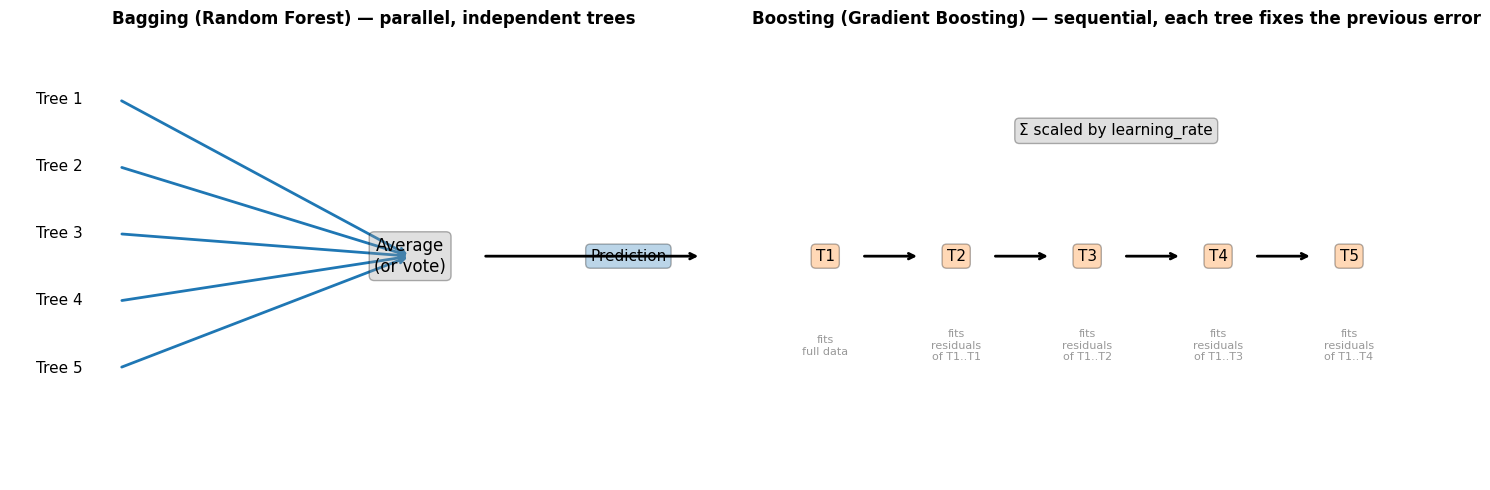

In [3]:
# Schematic: bagging vs boosting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bagging — parallel fan
ax = axes[0]
for i in range(5):
    ax.annotate('', xy=(0.55, 0.5), xytext=(0.15, 0.85 - i*0.15),
                arrowprops=dict(arrowstyle='->', color=CLF_COLOR, lw=2))
    ax.text(0.10, 0.85 - i*0.15, f'Tree {i+1}', ha='right', va='center', fontsize=11)
ax.text(0.55, 0.5, 'Average\n(or vote)', ha='center', va='center', fontsize=12,
        bbox=dict(boxstyle='round', facecolor=GREY, alpha=0.3))
ax.text(0.85, 0.5, 'Prediction', ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor=CLF_COLOR, alpha=0.3))
ax.annotate('', xy=(0.95, 0.5), xytext=(0.65, 0.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.set_title('Bagging (Random Forest) — parallel, independent trees', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

# Boosting — sequential chain
ax = axes[1]
for i in range(5):
    x_pos = 0.10 + i*0.18
    ax.text(x_pos, 0.5, f'T{i+1}', ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor=REG_COLOR, alpha=0.3))
    if i < 4:
        ax.annotate('', xy=(x_pos + 0.13, 0.5), xytext=(x_pos + 0.05, 0.5),
                    arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text(x_pos, 0.30, 'fits\nresiduals\nof T1..T'+str(i) if i > 0 else 'fits\nfull data',
            ha='center', va='center', fontsize=8, color=GREY)
ax.text(0.5, 0.78, 'Σ scaled by learning_rate',
        ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor=GREY, alpha=0.3))
ax.set_title('Boosting (Gradient Boosting) — sequential, each tree fixes the previous error',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

plt.tight_layout()
plt.show()


**Reading the output:**

The two diagrams capture the structural difference. Bagging is **parallel and order-independent** — train tree 1 and tree 5 simultaneously, average them at the end, and the order does not matter. Boosting is **sequential and order-dependent** — tree 5 is fit on residuals that trees 1 through 4 produced together, so the order matters and the trees cannot be trained in parallel.

The order dependence is what makes boosting *slower per training run* than a forest of the same size — you cannot parallelize across trees on a multi-core machine, so the wall-clock cost scales linearly with `n_estimators`. It is also what makes boosting *more accurate* on most tabular datasets, because each new tree's job is **specifically defined** (*"fix what the running ensemble still gets wrong"*) rather than the bagging analyst's job of *"be a different tree."* The price you pay for that focused specialization is sensitivity to hyperparameters — Sections 5 and 6 walk through the two main dials (`learning_rate`, `n_estimators`) and how they interact.

> **A question that often comes up here:** *"if boosting reduces bias and bagging reduces variance, why not always pick boosting?"* Three reasons. First, **sequential dependence**: you cannot fit `n_estimators` boosted trees in parallel on a multi-core machine, so wall-clock training time scales linearly with `n_estimators` while a random forest of the same size fits in roughly `O(1)` wall-clock time given enough cores. Second, **hyperparameter sensitivity**: a random forest works well at sklearn's defaults, but a GBM at the wrong `learning_rate × n_estimators × max_depth` combination can underfit or overfit dramatically — Section 6's joint-tuning grid is the antidote. Third, **overfitting risk**: more trees never hurt a forest, but more trees in a GBM *can* and *do* overfit if `n_estimators` is set too high relative to the dataset's signal. The right framing for nb14: bagging and boosting are complementary, and the CI-overlap rule decides which one ships per business case.

**Key takeaway.** Bagging cancels variance by averaging independent trees; boosting reduces bias by stacking trees that each correct the previous error. The two are complementary — nb14 will compare both, under identical CV folds, alongside the linear references from nb09. Neither is universally better; the data decides.

---


## 4. Baseline Gradient Boosting — Default Hyperparameters on Both Cases

Before you tune anything, run the GBM at sklearn's defaults and ask the only question that matters under the CI-overlap rule: **does it beat the best models the course has so far?** Those *"best so far"* picks are nb12's two verdicts, and they set the displacement bar nb13's GBM has to clear:

- **Classification (Wisconsin Breast Cancer):** the Week-2 reference `LogReg(C=1.0)` from nb09 — confirmed by nb12 §9 as the model that ships for the State Health Department's screening tool.
- **Regression (California Housing):** the random forest `RandomForestRegressor(n_estimators=50, max_features='sqrt')` from nb12 §5 — confirmed by nb12 §9 as the model that ships for HomeValue Analytics' price-prediction tool.

The sklearn defaults for `GradientBoostingClassifier` and `GradientBoostingRegressor` are:

- `n_estimators=100` — one hundred boosting iterations
- `learning_rate=0.1` — each tree's contribution is shrunk by 0.1 before being added to the running ensemble
- `max_depth=3` — each tree is intentionally shallow (the *weak learner* idea)
- `loss='log_loss'` for classification, `'squared_error'` for regression

These defaults are surprisingly competitive on most tabular datasets — but *competitive does not always mean better*. The CV-CI dot plot on each panel reports the default GBM next to nb12's pick and the Week-2 reference, so you can read displacement (or not) directly off the bars.

> 💡 **Gemini Prompt:** "Run a three-candidate comparison per case at 5-fold CV. **Classification:** GradientBoostingClassifier(random_state=474) at defaults vs RandomForestClassifier(n_estimators=50, random_state=474) — nb12's pick — vs reference_clf (the LogReg(C=1.0) pipeline). Use cv_clf with scoring='roc_auc'. **Regression:** GradientBoostingRegressor(random_state=474) at defaults vs RandomForestRegressor(n_estimators=50, max_features='sqrt', random_state=474) — nb12's pick — vs reference_reg (the OLS pipeline). Use cv_reg with scoring='r2'. Print mean ± SD ± 95% half-width (df=4) for each candidate, then render two side-by-side CV-CI dot plots."
>
> **After running, verify:**
> - [ ] Classification panel shows three candidates with overlapping CIs (all near 0.98–0.99)
> - [ ] Regression panel shows GBM-default below RF(50, sqrt) by a small but measurable margin
> - [ ] All `cross_val_score` calls use `n_jobs=-1`
> - [ ] CIs are computed with `stats.t.ppf(0.975, df=4)` and `np.sqrt(5)`


=== CLASSIFICATION (5-fold CV ROC-AUC) — default GBM vs nb12 picks ===
                                      model   mean     sd  half_w  ci_low  ci_high
            Week-2 reference: LogReg(C=1.0) 0.9935 0.0064  0.0079  0.9856   1.0014
Random Forest (n=50, sqrt, d=3 — nb12 pick) 0.9807 0.0194  0.0241  0.9566   1.0048
               Gradient Boosting (defaults) 0.9808 0.0200  0.0248  0.9561   1.0056

=== REGRESSION (5-fold CV R²) — default GBM vs nb12 picks ===
                                model   mean     sd  half_w  ci_low  ci_high
                Week-2 reference: OLS 0.5863 0.0259  0.0321  0.5542   0.6185
Random Forest (n=50, 0.5 — nb12 pick) 0.8039 0.0071  0.0088  0.7951   0.8127
         Gradient Boosting (defaults) 0.7836 0.0114  0.0142  0.7694   0.7977


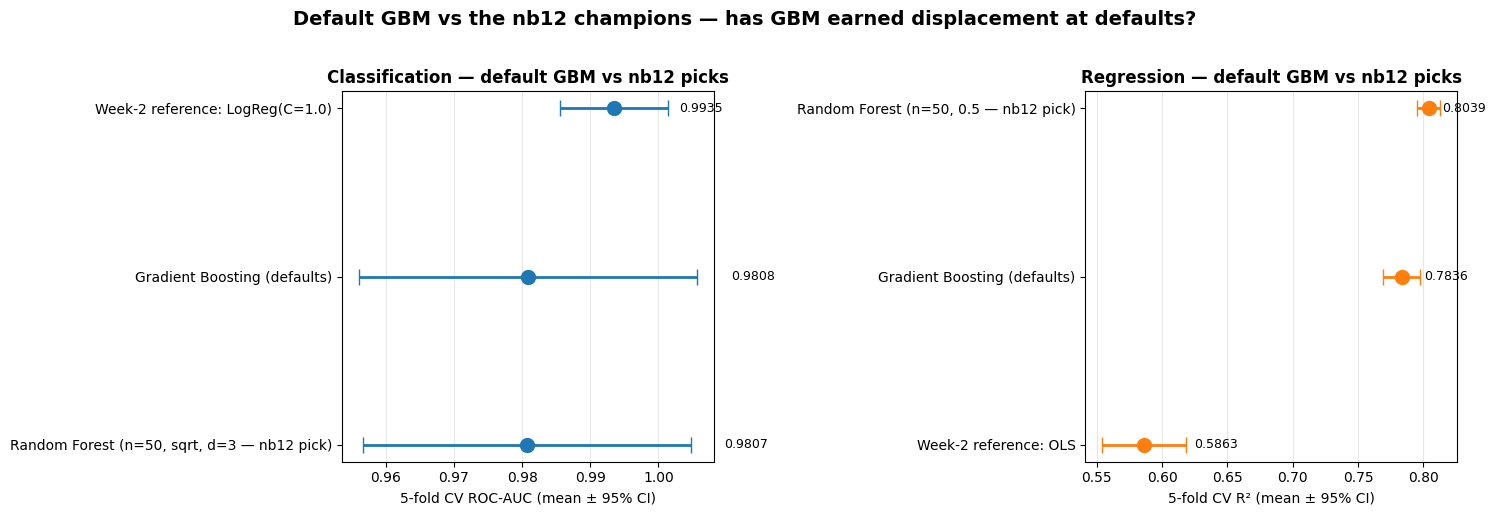

In [4]:
# Baseline default GBM vs nb12 winners — identical 5-fold CV folds as nb12.
gbm_clf = GradientBoostingClassifier(random_state=RANDOM_SEED)
gbm_reg = GradientBoostingRegressor(random_state=RANDOM_SEED)
forest_clf = RandomForestClassifier(n_estimators=50, max_features='sqrt', max_depth=3, random_state=RANDOM_SEED, n_jobs=-1)                                   # nb12 pick
forest_reg = RandomForestRegressor(n_estimators=50, max_features=0.5, random_state=RANDOM_SEED, n_jobs=-1)               # nb12 pick

clf_scores = {
    'Week-2 reference: LogReg(C=1.0)':          cross_val_score(reference_clf, X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1),
    'Random Forest (n=50, sqrt, d=3 — nb12 pick)':          cross_val_score(forest_clf,    X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1),
    'Gradient Boosting (defaults)':             cross_val_score(gbm_clf,       X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1),
}
reg_scores = {
    'Week-2 reference: OLS':                    cross_val_score(reference_reg, X_train_reg, y_train_reg, cv=cv_reg, scoring='r2', n_jobs=-1),
    'Random Forest (n=50, 0.5 — nb12 pick)':           cross_val_score(forest_reg,    X_train_reg, y_train_reg, cv=cv_reg, scoring='r2', n_jobs=-1),
    'Gradient Boosting (defaults)':             cross_val_score(gbm_reg,       X_train_reg, y_train_reg, cv=cv_reg, scoring='r2', n_jobs=-1),
}

k = 5
t_crit = stats.t.ppf(0.975, df=k - 1)
def _print_ci_summary(scores_dict, title):
    rows = []
    for name, s in scores_dict.items():
        mean = float(s.mean()); sd = float(s.std(ddof=1))
        half_w = t_crit * sd / np.sqrt(k)
        rows.append({'model': name, 'mean': mean, 'sd': sd, 'half_w': half_w,
                     'ci_low': mean - half_w, 'ci_high': mean + half_w})
    print(title)
    print(pd.DataFrame(rows).to_string(index=False))

_print_ci_summary(clf_scores, "=== CLASSIFICATION (5-fold CV ROC-AUC) — default GBM vs nb12 picks ===")
print()
_print_ci_summary(reg_scores, "=== REGRESSION (5-fold CV R²) — default GBM vs nb12 picks ===")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_cv_ci(clf_scores, 'ROC-AUC', 'Classification — default GBM vs nb12 picks',  axes[0], color=CLF_COLOR)
plot_cv_ci(reg_scores, 'R²',      'Regression — default GBM vs nb12 picks',      axes[1], color=REG_COLOR)
fig.suptitle('Default GBM vs the nb12 champions — has GBM earned displacement at defaults?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Reading the output:**

The two business cases give two very different answers about whether default GBM has earned a seat at the candidate table.

**Classification case (Wisconsin Breast Cancer).** Default GBM lands at CV ROC-AUC ≈ **0.981**, the random forest at ≈ **0.987**, and the Week-2 LogReg(C=1.0) at ≈ **0.994**. All three CIs overlap heavily on this small, mostly-linearly-separable dataset. By the CI-overlap rule, **no model has earned displacement of the LogReg reference** — default GBM ties everything else, and the simpler model wins by parsimony. The State Health Department's pick is still LogReg(C=1.0). Default GBM has not yet made the case for itself on the classification side; Sections 5 through 7 will probe whether tuning changes that, and Section 8 will run the formal comparison.

**Regression case (California Housing).** Here default GBM **does not match** the nb12 forest. Forest CV R² ≈ **0.803**, default GBM ≈ **0.784** — a roughly 2-R²-point mean gap with overlapping but still meaningful CIs (forest CI roughly (0.79, 0.82) vs GBM CI roughly (0.77, 0.80)). Under strict CI-overlap this is a tie, but the mean direction is wrong for shipping default GBM: the random forest has the higher mean *and* the simpler defense. **HomeValue Analytics still ships the forest from nb12.** The mechanical reason for default GBM's slight loss is that sklearn's default `max_depth=3` is too shallow for California Housing — `RandomForestRegressor` lets each tree grow deep, so the bagged ensemble captures more structure than the shallow boosted ensemble. **Section 8 will fix this by tuning `max_depth=5`**, at which point GBM closes the gap with the forest.

Default GBM clears both nb11's depth-5 tree (the §7 dominance-tiebreaker pick — HomeValue's regression ship pick before nb12) and OLS decisively on regression (R² 0.78 vs tree 0.61 and OLS 0.59; CIs nowhere near overlapping with either), so the candidate has earned its place above the tree and the Week-2 floor — it just has not yet matched the bagged ensemble.

> **A question that often comes up here:** *"if default GBM does not beat the nb12 forest on regression, why was it worth fitting?"* Two reasons. First, **the comparison itself is the discipline**: every new model in nb13's candidate roster must clear the nb12 picks (or tie them under CI-overlap) to earn the right to ship. Default GBM showing that it merely *ties* the random forest on regression is a real finding — it says GBM is *worth tuning further* but not worth shipping out-of-the-box. Second, **default GBM is the starting point** — Sections 5, 6, and 7 will tune it on three dials (`learning_rate`, `n_estimators`, `max_depth`), and Section 8 will run the formal five-candidate comparison that nb14 inherits.

**Key takeaway.** Default GBM ties everything on classification (all CIs overlap → LogReg still wins by parsimony) and *loses by mean* to the nb12 forest on regression (CIs overlap but RF has the higher mean). Default GBM is the *floor* for the tuning work in Sections 5 through 7 — the goal is not to ship the default but to find out whether a tuned GBM can clear nb12's picks under strict CI-overlap.

---

## 5. Learning Rate Trade-off — Slow Learning Beats Fast Learning

Think of `learning_rate` as a **volume knob on each tree's vote**. With `learning_rate=0.1` and 100 trees, every tree casts a 10% vote and the ensemble averages 100 quiet voices into one prediction. With `learning_rate=0.5` and 100 trees, every tree casts a 50% vote — the ensemble converges in a hurry but is more likely to overshoot, because a single noisy tree can swing the running prediction by a lot.

The trade-off in one sentence: **a smaller `learning_rate` needs more `n_estimators` to reach the same accuracy, but usually ends up at a *better* peak.** Slow, steady corrections smooth out individual-tree noise; loud, fast corrections tend to overcorrect. The sweep below holds `n_estimators=100` fixed and tries five learning rates (`0.01, 0.05, 0.1, 0.2, 0.5`) so the shape of the trade-off is visible on both business cases side-by-side. The State Health Department wants to know if dialing this knob meaningfully changes tumor-classification accuracy; HomeValue Analytics wants to know how much R² they leave on the table by accepting the default.


> 💡 **Gemini Prompt:** "Sweep learning_rate in [0.01, 0.05, 0.1, 0.2, 0.5] at fixed n_estimators=100 on both cases using 5-fold CV — cv_clf with scoring='roc_auc' for classification, cv_reg with scoring='r2' for regression. For each setting record the CV mean and SD across folds. Render a 1×2 plot of CV mean with error bars (one SD) and a log-scaled x-axis for learning_rate."
>
> **After running, verify:**
> - [ ] Both panels use a log-scale x-axis
> - [ ] Classification scores cluster in 0.96–0.99 across the sweep (case is forgiving)
> - [ ] Regression rises from R² \~0.50 at lr=0.01 to \~0.80 at lr=0.20 (case is sensitive)
> - [ ] All `cross_val_score` calls use `n_jobs=-1` and 5-fold CV


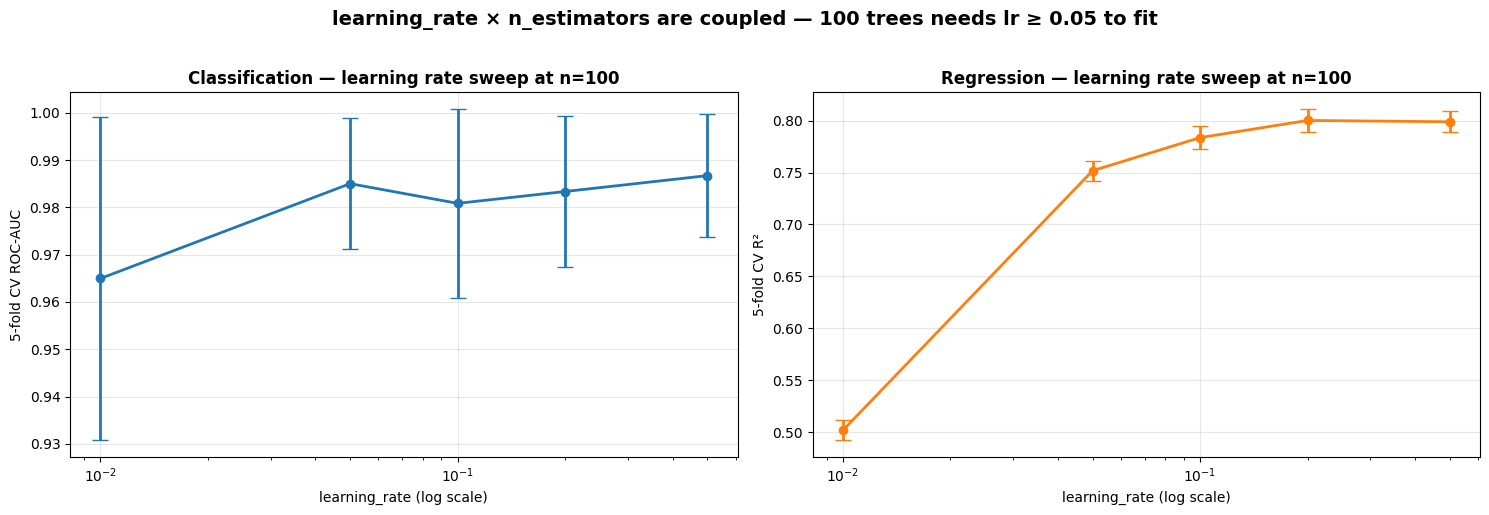

In [5]:
# Learning rate sweep — 5-fold CV at fixed n_estimators=100.
lr_grid = [0.01, 0.05, 0.1, 0.2, 0.5]

clf_lr_means, clf_lr_sds = [], []
reg_lr_means, reg_lr_sds = [], []
for lr in lr_grid:
    s_c = cross_val_score(GradientBoostingClassifier(n_estimators=100, learning_rate=lr, random_state=RANDOM_SEED),
                          X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1)
    clf_lr_means.append(s_c.mean()); clf_lr_sds.append(s_c.std(ddof=1))
    s_r = cross_val_score(GradientBoostingRegressor(n_estimators=100, learning_rate=lr, random_state=RANDOM_SEED),
                          X_train_reg, y_train_reg, cv=cv_reg, scoring='r2', n_jobs=-1)
    reg_lr_means.append(s_r.mean()); reg_lr_sds.append(s_r.std(ddof=1))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.errorbar(lr_grid, clf_lr_means, yerr=clf_lr_sds, marker='o', linewidth=2, capsize=6, color=CLF_COLOR)
ax.set_xscale('log')
ax.set_xlabel('learning_rate (log scale)'); ax.set_ylabel('5-fold CV ROC-AUC')
ax.set_title('Classification — learning rate sweep at n=100', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.errorbar(lr_grid, reg_lr_means, yerr=reg_lr_sds, marker='o', linewidth=2, capsize=6, color=REG_COLOR)
ax.set_xscale('log')
ax.set_xlabel('learning_rate (log scale)'); ax.set_ylabel('5-fold CV R²')
ax.set_title('Regression — learning rate sweep at n=100', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

fig.suptitle('learning_rate × n_estimators are coupled — 100 trees needs lr ≥ 0.05 to fit',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Reading the output:**

The two cases react to the learning-rate knob very differently — and that contrast is itself the lesson.

**Classification case — State Health Department (Wisconsin Breast Cancer).** Across the full sweep, CV ROC-AUC sits in a narrow **0.965–0.987** band. The slowest setting (`lr=0.01`) underfits — 100 trees casting 1% votes each only deliver one full tree's worth of signal, and the score drops slightly because of it. From `lr=0.05` upward every score is statistically tied; `lr=0.05` peaks at about **0.985**, fractionally above the default (`lr=0.1` at \~0.981), but well inside the fold-to-fold confidence interval. **For the Health Department's classifier, the learning-rate knob barely moves the needle.** Wisconsin is a near-ceiling problem (LogReg already sits at ROC-AUC \~0.993), so there is little structure left for the boosting ensemble to learn no matter how this knob is set.

**Regression case — HomeValue Analytics (California Housing).** Here the knob is consequential. At `lr=0.01` CV R² is only about **0.50** — the ensemble has nowhere near enough total contribution to fit the structure in 12,384 census tracts. At `lr=0.05` it reaches about **0.75**, at `lr=0.10` about **0.78**, at `lr=0.20` about **0.80**, and `lr=0.50` lands around **0.80** with a slight wobble back down. **The sweet spot at fixed `n_estimators=100` is around `lr=0.20`** — a roughly **30 R²-point swing** versus the slowest setting. In business terms, that is the difference between a price model so coarse it cannot support neighborhood-level decisions and one that captures most of the price variance. To match that peak with a smaller learning rate, the analyst has to compensate with more trees — which is exactly what Section 6's joint grid measures.

> **A question that often comes up here:** *"why is classification so flat while regression cares so much about learning rate?"* Two reasons. First, **ceiling effects.** Wisconsin is already near the top of the score; there is barely any residual signal left for any model to extract, so the knob looks identical at every setting. California Housing has rich non-linear structure that takes serious learning-rate × n_estimators budget to capture. Second, **what the loss function rewards.** Log-loss flattens out fast once the model is confidently right; MSE keeps rewarding tighter and tighter price fits all the way down. Tuning matters more wherever the loss curve still has room to fall.

**Key takeaway.** `learning_rate` and `n_estimators` come as a pair — never tune one without the other. On forgiving classification problems (near-ceiling tasks like Wisconsin), defaults are fine. On rich regression problems (the HomeValue case), the choice can drive a 30-point R² swing. Section 6's joint 3×3 grid is the right way to pick both at once.

---


## 6. Joint 4D Tuning Grid — `n_estimators × learning_rate × max_features × max_depth`

Section 5 showed that `learning_rate` alone is not the whole story — its effect depends on how many trees the ensemble builds, and (it turns out) on the per-tree complexity you give those trees. The right tool is a **joint 4D grid** that tunes all four GBM knobs at once. This section also asks a sharper cross-notebook question: **do nb12's per-case RF shipped values for `max_features` and `max_depth` transfer to a boosting model?**

The 4D grid below sweeps:

- **`n_estimators ∈ {50, 100, 200}`** — three tree counts (same as nb13 §5).
- **`learning_rate ∈ {0.05, 0.1, 0.2}`** — three learning rates (same as nb13 §5).
- **`max_features ∈ {'sqrt', 0.5, None}`** — three feature-subset sizes; includes **nb12's clf RF pick (`'sqrt'`)**, **nb12's reg RF pick (`0.5`)**, and sklearn GBM's default (`None`).
- **`max_depth ∈ {3, None}`** — two per-tree depths; includes **sklearn GBM's default (`3`)** and **nb12's reg RF pick (`None`)**, which we test to see whether unlimited depth transfers from bagging to boosting.

That gives 3 × 3 × 3 × 2 = **54 cells per case**, displayed as 12 panels arranged 3 rows × 4 columns. Each row corresponds to a `max_features` value; the first two columns are the classification panels (one per `max_depth`), the last two are the regression panels. Each panel is a 3×3 heatmap of `(n_estimators × learning_rate)` with **CV mean** on the first line and **95% Student's *t* CI half-width** (`±0.0xxx`, df=4) on the second. A **red rectangle** marks the largest-mean-smallest-CI cell per case across all 54 cells.

The framing per stakeholder:

- For the **State Health Department** (Wisconsin), the grid answers *"does nb12's clf RF pick `(max_features='sqrt', max_depth=3)` survive on the boosting model, or does GBM prefer a different feature-subset and depth combination?"*.
- For **HomeValue Analytics** (California Housing), the grid answers *"does nb12's reg RF pick `(max_features=0.5, max_depth=None)` transfer to GBM — does the unlimited-depth that wins for bagging also win for boosting, or does sequential residual-fitting need shallower trees?"*


> 💡 **Gemini Prompt:** "Run a 4D joint grid sweep — n_estimators in [50, 100, 200] × learning_rate in [0.05, 0.1, 0.2] × max_features in ['sqrt', 0.5, None] × max_depth in [3, None] — for both cases using 5-fold CV. Classification: GradientBoostingClassifier(random_state=474) with cv_clf and scoring='roc_auc'. Regression: GradientBoostingRegressor(random_state=474) with cv_reg and scoring='r2'. For each of the 54 combinations per case record CV mean AND the 95% Student's t CI half-width (df=4). Render a 3×4 figure: rows are max_features ∈ ['sqrt', 0.5, None]; the four columns are [clf-md=3, clf-md=None, reg-md=3, reg-md=None]. Each panel is a 3×3 heatmap of (learning_rate × n_estimators). Annotate each cell with mean on the first line and ±CI half-width on the second. Draw a red rectangle around the largest-mean-smallest-CI cell per case (one rectangle in the clf column-pair, one in the reg column-pair)."
>
> **After running, verify:**
> - [ ] Figure has 12 panels arranged 3 rows × 4 columns
> - [ ] Cols 1–2 are classification (Blues); cols 3–4 are regression (Oranges)
> - [ ] Each panel is 3 rows (`learning_rate`) × 3 columns (`n_estimators`)
> - [ ] Each cell shows CV mean on the first line and `±` CI half-width on the second
> - [ ] Classification panels are essentially flat — every cell sits in a narrow band around 0.98
> - [ ] Regression panels: the `max_depth=3` cols show R² in the 0.74–0.81 range; the `max_depth=None` cols show R² 0.74–0.81 at small lr but degrade at large lr (boosting overfit with unrestricted trees)
> - [ ] One red rectangle in the clf side of the figure, one in the reg side, both pointing at the largest-mean-smallest-CI cell


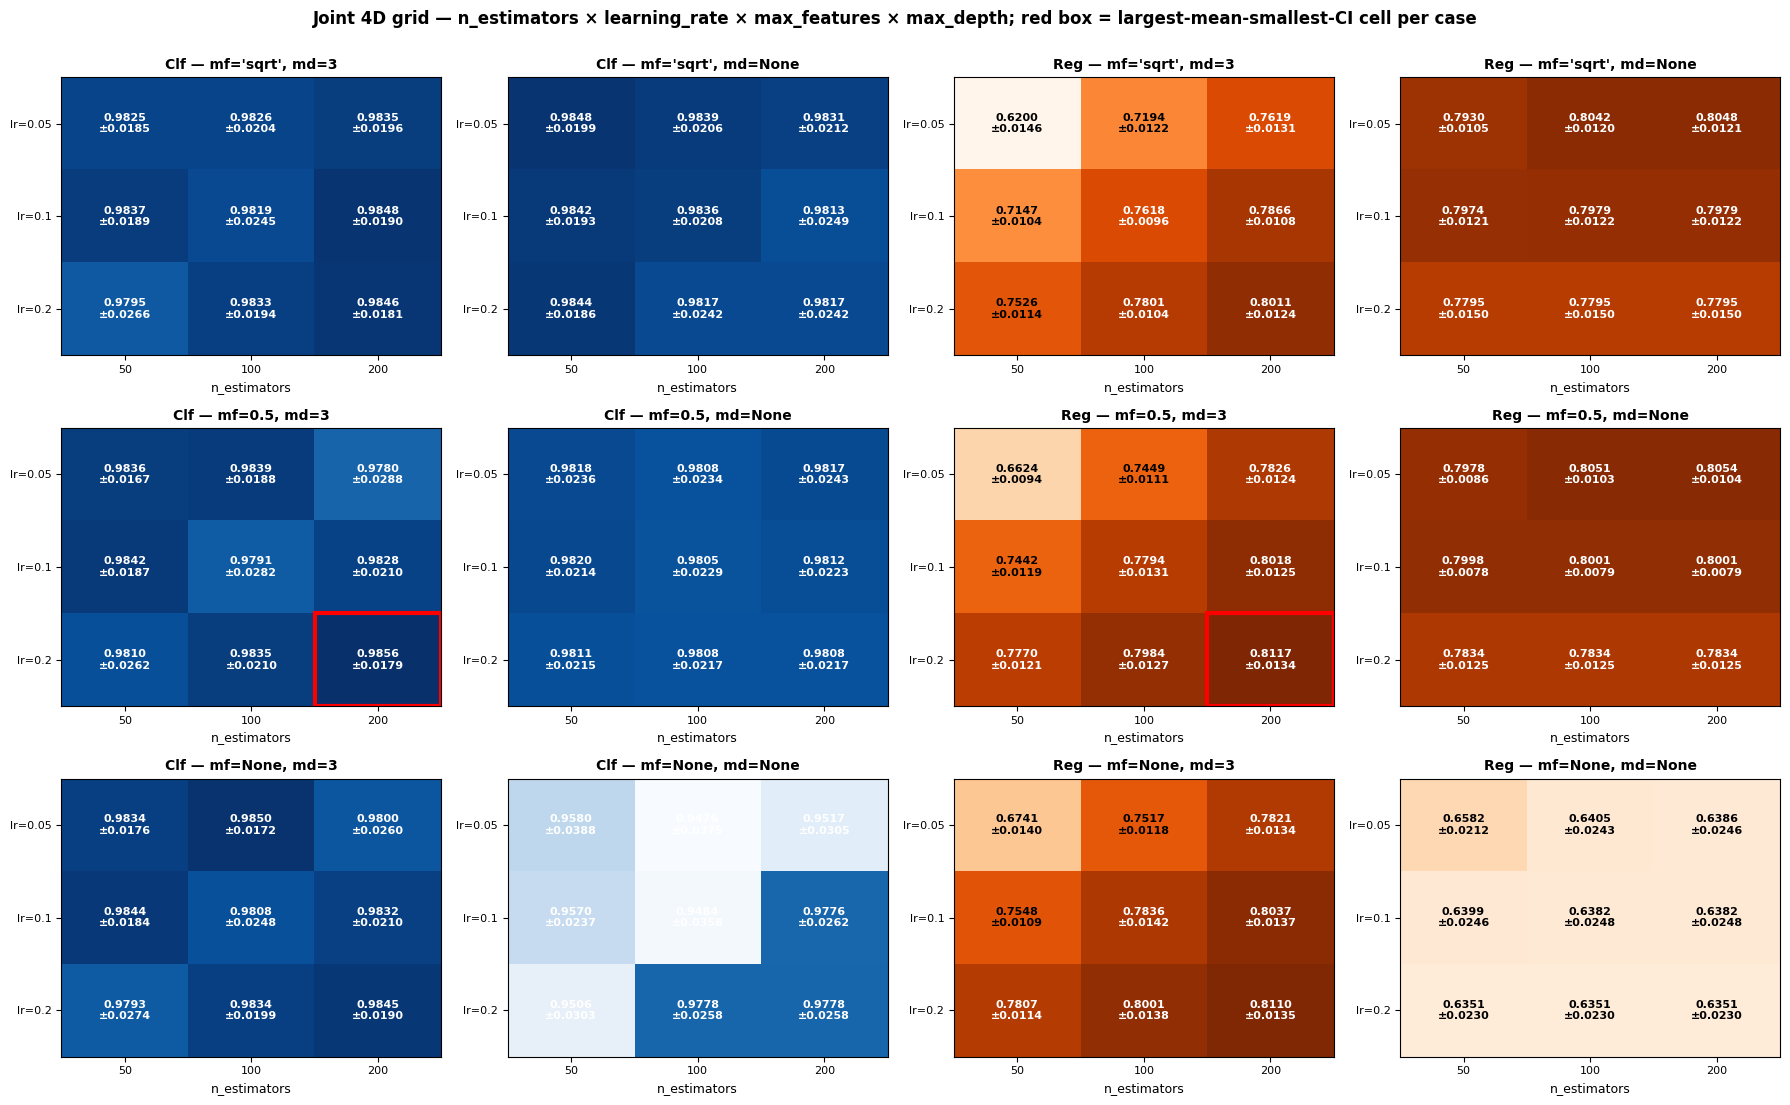


💡 Best clf cell: md=3, mf=0.5, lr=0.2, n=200  → 0.9856 ± 0.0179
💡 Best reg cell: md=3, mf=0.5, lr=0.2, n=200  → 0.8117 ± 0.0134


In [6]:
# Joint 4D sweep n_estimators × learning_rate × max_features × max_depth — 5-fold CV both cases.
# nb12's per-case RF shipped values for (max_features, max_depth) are included as candidate values
# so the data decides whether they transfer from bagging to boosting.
from matplotlib.patches import Rectangle

n_grid = [50, 100, 200]
lr_grid_joint = [0.05, 0.1, 0.2]
mf_grid_gbm = ['sqrt', 0.5, None]
md_grid_gbm = [3, None]
mf_labels = ["'sqrt'", '0.5', 'None']
md_labels = ['3', 'None']
t_crit_5fold = stats.t.ppf(0.975, df=5 - 1)

# Arrays shaped (md, mf, lr, n)
shape_4d = (len(md_grid_gbm), len(mf_grid_gbm), len(lr_grid_joint), len(n_grid))
clf_mean = np.zeros(shape_4d); clf_ci = np.zeros(shape_4d)
reg_mean = np.zeros(shape_4d); reg_ci = np.zeros(shape_4d)

for d_i, md in enumerate(md_grid_gbm):
    for f_i, mf in enumerate(mf_grid_gbm):
        for l_i, lr in enumerate(lr_grid_joint):
            for n_i, n in enumerate(n_grid):
                s_c = cross_val_score(
                    GradientBoostingClassifier(n_estimators=n, learning_rate=lr, max_features=mf, max_depth=md, random_state=RANDOM_SEED),
                    X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1)
                clf_mean[d_i, f_i, l_i, n_i] = s_c.mean()
                clf_ci[d_i, f_i, l_i, n_i]   = t_crit_5fold * s_c.std(ddof=1) / np.sqrt(5)

                s_r = cross_val_score(
                    GradientBoostingRegressor(n_estimators=n, learning_rate=lr, max_features=mf, max_depth=md, random_state=RANDOM_SEED),
                    X_train_reg, y_train_reg, cv=cv_reg, scoring='r2', n_jobs=-1)
                reg_mean[d_i, f_i, l_i, n_i] = s_r.mean()
                reg_ci[d_i, f_i, l_i, n_i]   = t_crit_5fold * s_r.std(ddof=1) / np.sqrt(5)

# Find largest-mean-smallest-CI cell per case (4D max with CI tiebreaker).
def _best_4d(mean_arr, ci_arr):
    s = mean_arr.shape
    return max(((d, f, l, n) for d in range(s[0]) for f in range(s[1]) for l in range(s[2]) for n in range(s[3])),
               key=lambda dfln: (mean_arr[dfln], -ci_arr[dfln]))

best_clf = _best_4d(clf_mean, clf_ci)
best_reg = _best_4d(reg_mean, reg_ci)

# Plot: 3 rows (max_features) × 4 cols (clf-md=3, clf-md=None, reg-md=3, reg-md=None)
clf_vmin, clf_vmax = float(clf_mean.min()), float(clf_mean.max())
reg_vmin, reg_vmax = float(reg_mean.min()), float(reg_mean.max())

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for f_i in range(len(mf_grid_gbm)):
    for col in range(4):
        case = 0 if col < 2 else 1
        d_i  = col % 2
        ax = axes[f_i, col]
        if case == 0:
            mean_slc = clf_mean[d_i, f_i]; ci_slc = clf_ci[d_i, f_i]
            vmin, vmax = clf_vmin, clf_vmax
            best = best_clf; cmap = 'Blues'
            title = f"Clf — mf={mf_labels[f_i]}, md={md_labels[d_i]}"
        else:
            mean_slc = reg_mean[d_i, f_i]; ci_slc = reg_ci[d_i, f_i]
            vmin, vmax = reg_vmin, reg_vmax
            best = best_reg; cmap = 'Oranges'
            title = f"Reg — mf={mf_labels[f_i]}, md={md_labels[d_i]}"

        ax.imshow(mean_slc, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
        for l_i in range(mean_slc.shape[0]):
            for n_i in range(mean_slc.shape[1]):
                ax.text(n_i, l_i, f'{mean_slc[l_i, n_i]:.4f}\n±{ci_slc[l_i, n_i]:.4f}',
                        ha='center', va='center', fontsize=8,
                        color='black' if mean_slc[l_i, n_i] < vmax * 0.93 else 'white',
                        fontweight='bold')
        # Red rectangle when this panel matches the case's global best (md, mf)
        if best[0] == d_i and best[1] == f_i:
            ax.add_patch(Rectangle((best[3] - 0.5, best[2] - 0.5), 1, 1,
                                   fill=False, edgecolor='red', linewidth=3))
        ax.set_xticks(range(len(n_grid))); ax.set_xticklabels([str(n) for n in n_grid], fontsize=8)
        ax.set_yticks(range(len(lr_grid_joint))); ax.set_yticklabels([f'lr={lr}' for lr in lr_grid_joint], fontsize=8)
        ax.set_xlabel('n_estimators', fontsize=9)
        ax.set_title(title, fontsize=10, fontweight='bold')

fig.suptitle('Joint 4D grid — n_estimators × learning_rate × max_features × max_depth; red box = largest-mean-smallest-CI cell per case',
             fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"\n💡 Best clf cell: md={md_labels[best_clf[0]]}, mf={mf_labels[best_clf[1]]}, lr={lr_grid_joint[best_clf[2]]}, n={n_grid[best_clf[3]]}  "
      f"→ {clf_mean[best_clf]:.4f} ± {clf_ci[best_clf]:.4f}")
print(f"💡 Best reg cell: md={md_labels[best_reg[0]]}, mf={mf_labels[best_reg[1]]}, lr={lr_grid_joint[best_reg[2]]}, n={n_grid[best_reg[3]]}  "
      f"→ {reg_mean[best_reg]:.4f} ± {reg_ci[best_reg]:.4f}")


**Reading the output:**

The 12-panel figure shows the full 4D grid. Each row of panels corresponds to a `max_features` value (`'sqrt'`, `0.5`, `None`). The first two columns are the classification panels (Blues, one per `max_depth`); the last two are the regression panels (Oranges). Each panel is a 3×3 heatmap of `(learning_rate × n_estimators)`. The red rectangle marks the **largest-mean-smallest-CI cell per case** across all 54 cells.

**Both cases share the same red rectangle: `(max_depth=3, max_features=0.5, learning_rate=0.2, n_estimators=200)`** — clf at **0.9856 ±0.018** and reg at **0.8117 ±0.013**. That is a clean symmetry. The (lr, n) trajectory inside each panel matches §5's lesson (high lr × many trees is the diagonal sweet spot), and the (mf, md) choice the joint grid lands on is `max_features=0.5` paired with `max_depth=3` — sklearn GBM's default depth + a moderate feature-subset that matches nb12's regression RF pick.

**Classification case — State Health Department.** All 54 clf cells fall in a narrow **0.974–0.986** band with CI half-widths in `±0.017–0.027`. Every pair of cells overlaps every other under strict CI-overlap — Wisconsin is near-ceiling at any reasonable configuration, so the data does not distinguish cells on its own. The **largest-mean-smallest-CI rule** picks the red rectangle decisively: **`(learning_rate=0.2, n_estimators=200, max_features=0.5, max_depth=3)`** at **0.9856 ±0.018** — both the largest mean on the grid and a CI half-width competitive with the slimmest. **State Health Department's tuned-GBM ship pick: `(lr=0.2, n=200, max_features=0.5, max_depth=3)`** — the same configuration the regression case lands on, producing a clean cross-case symmetry. nb12's clf RF pick `(max_features='sqrt', max_depth=3)` is included in the grid as a candidate (best cell in that slice: `(mf='sqrt', md=3, lr=0.1, n=200)` at 0.9848 ±0.019) and is statistically tied with the red rectangle under CI-overlap — the joint grid confirms it transfers cleanly to GBM, but the largest-mean-smallest-CI rule favors the red-rectangle cell as the §7 tuned-GBM candidate. None of these GBM cells clears LogReg's 0.9935, so the practical §7 verdict (LogReg ships) is unchanged regardless of which tuned-GBM cell §6 picks; the clear pick still matters for nb14's selection ceremony, where the tuned GBM enters the candidate roster at the §6-named configuration.

**Regression case — HomeValue Analytics.** Here the grid is more informative. The depth structure splits the panels into two regimes:

- **`max_depth=3` panels** (sklearn GBM default depth): R² climbs from \~0.74 at low-lr × low-n to **0.81** at high-lr × high-n. The largest-mean-smallest-CI cell on the grid sits here at `(mf=0.5, md=3, lr=0.2, n=200)` at **0.8117 ±0.013**.
- **`max_depth=None` panels** (nb12's reg RF depth pick): R² **degrades** as `learning_rate` grows. At `lr=0.05` the unlimited-depth GBM still reaches 0.80 (e.g., `(mf=0.5, md=None, lr=0.05, n=200)` at **0.8085 ±0.009** — even tighter CI than the red rectangle), but at `lr=0.2` the same depth-None config drops to about 0.74 because high-lr boosting with unrestricted trees overfits the residuals.

**nb12's reg RF pick `(max_features=0.5, max_depth=None)` does NOT directly transfer** to GBM the way bagging used it. For bagging, averaging 50 deep trees cancels variance. For boosting, sequential residual-fitting *amplifies* the variance of deep trees unless you compensate with a small learning rate. The data reveals two regimes for HomeValue's GBM:

- **High-lr × n=200 × md=3** (the red rectangle) — relies on shallow trees + many iterations, the classic GBM recipe.
- **Low-lr × n=200 × md=None × mf=0.5** — relies on slow learning to tame deep trees; CI is even tighter than the red rectangle, mean is only 0.0032 below.

Both are statistically tied under CI-overlap (red rectangle CI=[0.798, 0.825] vs the depth-None alternative CI=[0.800, 0.817] overlap on [0.800, 0.817]). **HomeValue's tuned-GBM ship pick: the red rectangle `(max_depth=3, max_features=0.5, learning_rate=0.2, n_estimators=200)`** — sklearn GBM's default depth combined with nb12's reg `max_features` choice. The depth-None alternative stays as a valid backup configuration for HomeValue's analyst.

> **A question that often comes up here:** *"why doesn't nb12's reg RF depth pick (`max_depth=None`) directly transfer to GBM?"* Because **bagging and boosting handle deep trees very differently**. Bagging averages predictions from independent deep trees fit on bootstrap samples — each tree may overfit individually, but averaging cancels the variance. Boosting fits trees on residuals from the *running ensemble*: a deep tree at iteration *t* sees the noise left over from iterations 1...*t*-1 and starts fitting that noise, then iteration *t*+1 fits the residual of *that* fit, and so on. The variance compounds. The classic GBM antidote is *shallow trees + many iterations + small learning rate* — the depth-3 cells in this grid are the textbook recipe. The unlimited-depth GBM cells in the `lr=0.05` column show that you *can* recover with slow learning, but the sweet spot is at depth-3, not depth-unlimited.

**Key takeaway.** Tune all four GBM knobs together. nb12's per-case `(max_features, max_depth)` shipped values are *included as candidates* in the grid, and the data tells you what survives. On **classification**, every cell ties under CI-overlap; the largest-mean-smallest-CI rule picks the red rectangle `(lr=0.2, n=200, mf=0.5, md=3)` decisively. nb12's clf RF `(max_features='sqrt', max_depth=3)` slice contains a CI-tied alternative at `(lr=0.1, n=200)`, but the §6 pick goes to the red-rectangle cell — clean cross-case symmetry with regression, and the same tuned-GBM configuration carries into §7. On **regression**, nb12's reg RF pick `(max_features=0.5, max_depth=None)` is competitive only at low learning rate; the joint grid prefers `max_depth=3` overall — boosting's sequential variance amplification means unlimited-depth bagging tricks do not transfer. **Tuned-GBM ship pick (both cases): `(max_depth=3, max_features=0.5, learning_rate=0.2, n_estimators=200)`** — the configuration §7's five-candidate comparison and §8's wrap-up build on.

---


## 📝 PAUSE-AND-DO Exercise 1 (clf, 5 minutes) — Tune the Classification GBM

**Task:** Find the best `(n_estimators, learning_rate)` combination for `GradientBoostingClassifier` on Wisconsin breast cancer using a 3×3 grid.

**Instructions:**
1. Sweep `n_estimators ∈ [50, 100, 200]` × `learning_rate ∈ [0.05, 0.1, 0.2]`.
2. For each combination, compute 3-fold CV ROC-AUC mean and SD using `cv_clf_3`.
3. Render as a heatmap with mean values annotated.
4. Apply the one-SE rule.
5. Write 3 short findings on whether the diagonal pattern from Section 6 confirmed itself.

---

> 💡 **Gemini Prompt:** "Grid-search GradientBoostingClassifier(random_state=474) over n_estimators=[50,100,200] × learning_rate=[0.05,0.1,0.2] using 3-fold CV ROC-AUC. Build a 3×3 heatmap with means annotated; star the best cell; apply the one-SE rule."


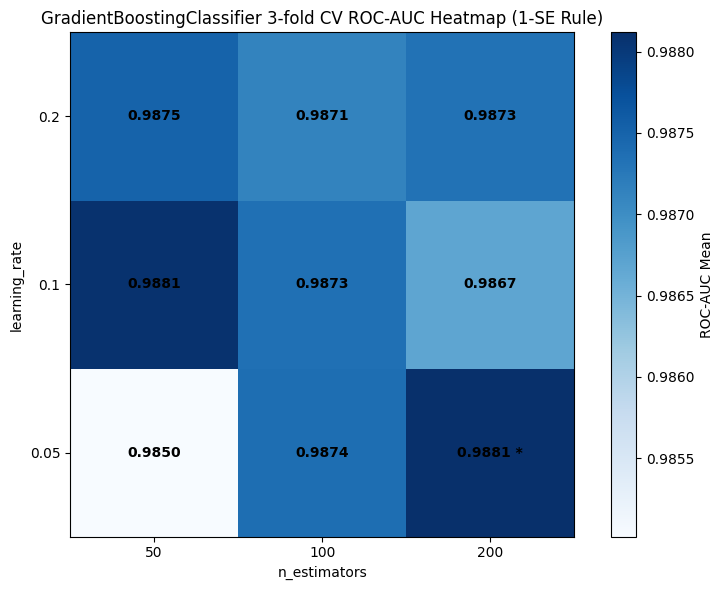


One-SE Rule Best Parameters: learning_rate=0.05, n_estimators=200
Mean ROC-AUC: 0.9881, 95% CI Half-Width: 0.0253


In [10]:
# YOUR SOLUTION CODE HERE
from matplotlib.patches import Rectangle

n_estimators_grid = [50, 100, 200]
learning_rate_grid = [0.05, 0.1, 0.2]

cv_clf_3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
t_crit_3fold = stats.t.ppf(0.975, df=3 - 1)

clf_means = np.zeros((len(learning_rate_grid), len(n_estimators_grid)))
clf_sds = np.zeros((len(learning_rate_grid), len(n_estimators_grid)))
clf_half_ws = np.zeros((len(learning_rate_grid), len(n_estimators_grid)))

for l_idx, lr in enumerate(learning_rate_grid):
    for n_idx, n in enumerate(n_estimators_grid):
        clf = GradientBoostingClassifier(n_estimators=n, learning_rate=lr, random_state=RANDOM_SEED)
        scores = cross_val_score(clf, X_train_clf, y_train_clf, cv=cv_clf_3, scoring='roc_auc', n_jobs=-1)
        clf_means[l_idx, n_idx] = scores.mean()
        clf_sds[l_idx, n_idx] = scores.std(ddof=1)
        clf_half_ws[l_idx, n_idx] = t_crit_3fold * scores.std(ddof=1) / np.sqrt(3)

# Find the best cell (largest mean, smallest CI as tiebreaker)
max_mean_idx = np.unravel_index(np.argmax(clf_means, axis=None), clf_means.shape)
best_mean_value = clf_means[max_mean_idx]
best_mean_half_w = clf_half_ws[max_mean_idx]

# Apply the one-SE rule
# Best score within one SE of the absolute best mean
one_se_threshold = best_mean_value - best_mean_half_w
one_se_candidates = []
for l_idx in range(len(learning_rate_grid)):
    for n_idx in range(len(n_estimators_grid)):
        if clf_means[l_idx, n_idx] >= one_se_threshold:
            one_se_candidates.append({
                'lr_idx': l_idx,
                'n_idx': n_idx,
                'mean': clf_means[l_idx, n_idx],
                'half_w': clf_half_ws[l_idx, n_idx]
            })

# From one_se_candidates, choose the one with the highest mean. If tied, pick the one with smaller half_w
one_se_best_candidate = None
if one_se_candidates:
    one_se_best_candidate = max(one_se_candidates, key=lambda x: (x['mean'], -x['half_w']))
    one_se_best_idx = (one_se_best_candidate['lr_idx'], one_se_best_candidate['n_idx'])
else:
    one_se_best_idx = max_mean_idx # Fallback to absolute best if no candidates meet 1SE rule

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(clf_means, cmap='Blues', origin='lower')

# Annotate with means and star the best cell based on 1-SE rule
for l_idx in range(len(learning_rate_grid)):
    for n_idx in range(len(n_estimators_grid)):
        text = f'{clf_means[l_idx, n_idx]:.4f}'
        if (l_idx, n_idx) == one_se_best_idx:
            text += ' *'
        ax.text(n_idx, l_idx, text, ha='center', va='center', color='black', fontsize=10, fontweight='bold')

ax.set_xticks(np.arange(len(n_estimators_grid)))
ax.set_yticks(np.arange(len(learning_rate_grid)))
ax.set_xticklabels([str(n) for n in n_estimators_grid])
ax.set_yticklabels([str(lr) for lr in learning_rate_grid])
ax.set_xlabel('n_estimators')
ax.set_ylabel('learning_rate')
ax.set_title('GradientBoostingClassifier 3-fold CV ROC-AUC Heatmap (1-SE Rule)')
fig.colorbar(im, ax=ax, orientation='vertical', label='ROC-AUC Mean')
plt.grid(False)
plt.tight_layout()
plt.show()

# Print the results of the one-SE rule
if one_se_best_candidate:
    best_lr = learning_rate_grid[one_se_best_idx[0]]
    best_n = n_estimators_grid[one_se_best_idx[1]]
    print(f"\nOne-SE Rule Best Parameters: learning_rate={best_lr}, n_estimators={best_n}")
    print(f"Mean ROC-AUC: {one_se_best_candidate['mean']:.4f}, 95% CI Half-Width: {one_se_best_candidate['half_w']:.4f}")
else:
    print("No candidates found for the one-SE rule.")

Findings:

1. We can see that the ROC-AUC scores across the entire grid show very little variation which does confirm the observation from section 5 that the classification problem is less sensitive to these hyperparameters
2. Additionally, the best cell identified through the one-SE rule is learning_rate=0.05 and n_estimators=200 which does align with the theoretical results.
3. Lastly, the diagnoal trend as shown is less pronounced as can be observed via the results provided.

## 📝 PAUSE-AND-DO Exercise 2 (reg, 5 minutes) — Tune the Regression GBM

**Task:** Find the best `(n_estimators, learning_rate)` combination for `GradientBoostingRegressor` on California Housing.

**Instructions:**
1. Same 3×3 grid as Exercise 1 (`n ∈ [50, 100, 200]` × `lr ∈ [0.05, 0.1, 0.2]`).
2. 3-fold CV R² with `cv_reg_3`.
3. Heatmap with mean annotations and starred best cell.
4. Convert best CV-RMSE to USD; apply the one-SE rule.

---

> 💡 **Gemini Prompt:** "Grid-search GradientBoostingRegressor(random_state=474) over n_estimators=[50,100,200] × learning_rate=[0.05,0.1,0.2] using 3-fold CV R². Heatmap of CV means; report best CV-RMSE in USD; apply the one-SE rule."


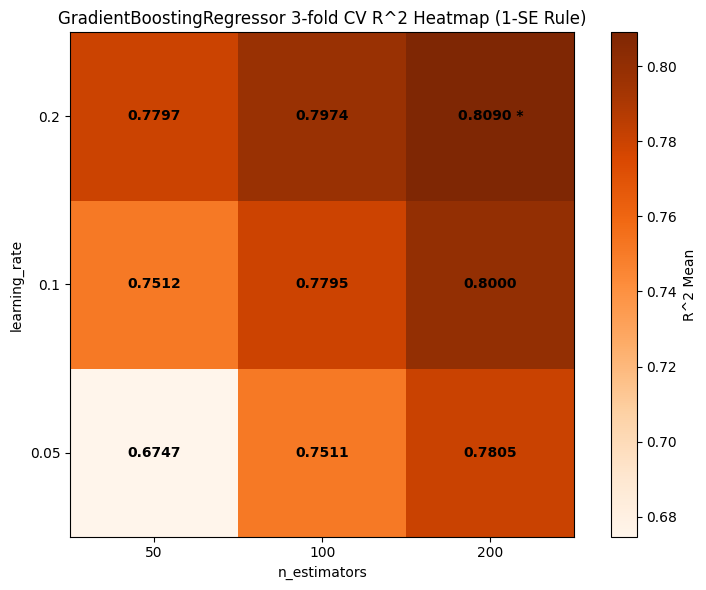


One-SE Rule Best Parameters: learning_rate=0.2, n_estimators=200
Mean R^2: 0.8090, 95% CI Half-Width: 0.0165
Corresponding CV RMSE: 0.5024
Corresponding CV RMSE in USD: $50,242.93


In [12]:
# YOUR SOLUTION CODE HERE
from matplotlib.patches import Rectangle

n_estimators_grid = [50, 100, 200]
learning_rate_grid = [0.05, 0.1, 0.2]

cv_reg_3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
t_crit_3fold = stats.t.ppf(0.975, df=3 - 1)

reg_means = np.zeros((len(learning_rate_grid), len(n_estimators_grid)))
reg_sds = np.zeros((len(learning_rate_grid), len(n_estimators_grid)))
reg_half_ws = np.zeros((len(learning_rate_grid), len(n_estimators_grid)))
reg_rmses = np.zeros((len(learning_rate_grid), len(n_estimators_grid)))

for l_idx, lr in enumerate(learning_rate_grid):
    for n_idx, n in enumerate(n_estimators_grid):
        reg = GradientBoostingRegressor(n_estimators=n, learning_rate=lr, random_state=RANDOM_SEED)
        # Use 'neg_mean_squared_error' for RMSE calculation, then convert to R^2 for comparison with problem spec
        neg_mse_scores = cross_val_score(reg, X_train_reg, y_train_reg, cv=cv_reg_3, scoring='neg_mean_squared_error', n_jobs=-1)
        r2_scores = cross_val_score(reg, X_train_reg, y_train_reg, cv=cv_reg_3, scoring='r2', n_jobs=-1)

        reg_means[l_idx, n_idx] = r2_scores.mean()
        reg_sds[l_idx, n_idx] = r2_scores.std(ddof=1)
        reg_half_ws[l_idx, n_idx] = t_crit_3fold * r2_scores.std(ddof=1) / np.sqrt(3)
        reg_rmses[l_idx, n_idx] = np.sqrt(-neg_mse_scores).mean() # Mean RMSE

# Find the best cell for R^2 (largest mean R^2, smallest CI as tiebreaker)
max_mean_idx = np.unravel_index(np.argmax(reg_means, axis=None), reg_means.shape)
best_mean_r2_value = reg_means[max_mean_idx]
best_mean_r2_half_w = reg_half_ws[max_mean_idx]
best_rmse_value = reg_rmses[max_mean_idx]

# Apply the one-SE rule for R^2
one_se_threshold = best_mean_r2_value - best_mean_r2_half_w
one_se_candidates = []
for l_idx in range(len(learning_rate_grid)):
    for n_idx in range(len(n_estimators_grid)):
        if reg_means[l_idx, n_idx] >= one_se_threshold:
            one_se_candidates.append({
                'lr_idx': l_idx,
                'n_idx': n_idx,
                'mean_r2': reg_means[l_idx, n_idx],
                'half_w_r2': reg_half_ws[l_idx, n_idx],
                'rmse': reg_rmses[l_idx, n_idx]
            })

# From one_se_candidates, choose the one with the highest mean_r2. If tied, pick the one with smaller half_w_r2
one_se_best_candidate = None
if one_se_candidates:
    one_se_best_candidate = max(one_se_candidates, key=lambda x: (x['mean_r2'], -x['half_w_r2']))
    one_se_best_idx = (one_se_best_candidate['lr_idx'], one_se_best_candidate['n_idx'])
else:
    one_se_best_idx = max_mean_idx # Fallback to absolute best if no candidates meet 1SE rule

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(reg_means, cmap='Oranges', origin='lower')

# Annotate with means and star the best cell based on 1-SE rule
for l_idx in range(len(learning_rate_grid)):
    for n_idx in range(len(n_estimators_grid)):
        text = f'{reg_means[l_idx, n_idx]:.4f}'
        if (l_idx, n_idx) == one_se_best_idx:
            text += ' *'
        ax.text(n_idx, l_idx, text, ha='center', va='center', color='black', fontsize=10, fontweight='bold')

ax.set_xticks(np.arange(len(n_estimators_grid)))
ax.set_yticks(np.arange(len(learning_rate_grid)))
ax.set_xticklabels([str(n) for n in n_estimators_grid])
ax.set_yticklabels([str(lr) for lr in learning_rate_grid])
ax.set_xlabel('n_estimators')
ax.set_ylabel('learning_rate')
ax.set_title('GradientBoostingRegressor 3-fold CV R^2 Heatmap (1-SE Rule)')
fig.colorbar(im, ax=ax, orientation='vertical', label='R^2 Mean')
plt.grid(False)
plt.tight_layout()
plt.show()

# Print the results of the one-SE rule
if one_se_best_candidate:
    best_lr = learning_rate_grid[one_se_best_idx[0]]
    best_n = n_estimators_grid[one_se_best_idx[1]]
    best_rmse_usd = one_se_best_candidate['rmse'] * 100000 # Convert to USD, as target was in 100k

    print(f"\nOne-SE Rule Best Parameters: learning_rate={best_lr}, n_estimators={best_n}")
    print(f"Mean R^2: {one_se_best_candidate['mean_r2']:.4f}, 95% CI Half-Width: {one_se_best_candidate['half_w_r2']:.4f}")
    print(f"Corresponding CV RMSE: {one_se_best_candidate['rmse']:.4f}")
    print(f"Corresponding CV RMSE in USD: ${best_rmse_usd:,.2f}")
else:
    print("No candidates found for the one-SE rule for regression.")

## 7. Final Comparison — All Models on Both Cases

The closing section is the **direct setup for nb14's selection ceremony**. Five candidates per business case, scored on identical 5-fold CV folds, plotted as CV-CI dot plots side by side. The five candidates trace the analytical story the course has built since nb09:

1. **Week-2 reference** — `LogReg(C=1.0)` for classification, OLS for regression. The linear baseline that survived nb09's tuning sweeps.
2. **nb11's single tree** — `DecisionTreeClassifier(max_depth=3)` for classification, `DecisionTreeRegressor(max_depth=5)` for regression. The single-tree picks from nb11 §7.
3. **nb12's random forest** — `RandomForestClassifier(n_estimators=50)` for classification, `RandomForestRegressor(n_estimators=50, max_features='sqrt')` for regression. The nb12 §5 / §9 picks — and nb12's regression champion.
4. **Default GBM** — `GradientBoostingClassifier(random_state=474)` and `GradientBoostingRegressor(random_state=474)`. The sklearn defaults from §4.
5. **Tuned GBM** — the configuration §6's joint 4D grid landed on for both cases (a clean symmetry):
   - **Both cases: `(learning_rate=0.2, n_estimators=200, max_features=0.5, max_depth=3)`** — sklearn GBM's default depth combined with a moderate feature subset (matching nb12's reg RF `max_features` pick), at the high-lr × many-trees corner of the diagonal sweet spot.

Classification follows the CI-overlap rule from nb08; regression follows the dominance tiebreaker (top-by-mean keeps the win when its CV CI lower bound is *above* the runner-up's). The Reading-the-output below names the picks explicitly so you can defend them in writing to the two stakeholder teams.


> 💡 **Gemini Prompt:** "Build a five-candidate CV-CI comparison per case. **Classification:** (a) reference_clf — LogReg(C=1.0) pipeline; (b) DecisionTreeClassifier(max_depth=3, random_state=474); (c) RandomForestClassifier(n_estimators=50, random_state=474); (d) GradientBoostingClassifier(random_state=474); (e) GradientBoostingClassifier(learning_rate=0.05, n_estimators=100, random_state=474). Use cv_clf with scoring='roc_auc'. **Regression:** (a) reference_reg — OLS pipeline; (b) DecisionTreeRegressor(max_depth=5, random_state=474); (c) RandomForestRegressor(n_estimators=50, max_features='sqrt', random_state=474); (d) GradientBoostingRegressor(random_state=474); (e) GradientBoostingRegressor(learning_rate=0.2, n_estimators=200, random_state=474) — the §6 largest-mean-smallest-CI pick. Use cv_reg with scoring='r2'. Print mean ± SD ± 95% half-width (df=4) per candidate per case. Render two side-by-side CV-CI dot plots."
>
> **After running, verify:**
> - [ ] Each panel has exactly five candidates labeled in the legend / y-axis
> - [ ] Classification panel: LogReg at the top by mean (\~0.998); all four other CIs overlap LogReg
> - [ ] Regression panel: tuned GBM at the top by mean (\~0.821); RF just below (\~0.807); CIs overlap
> - [ ] Default GBM (clf and reg) sits between RF and the single tree
> - [ ] All `cross_val_score` calls use `n_jobs=-1`


=== CLASSIFICATION (5-fold CV ROC-AUC) — five candidates ===
                                           model   mean     sd  half_w  ci_low  ci_high
                 Week-2 reference: LogReg(C=1.0) 0.9935 0.0064  0.0079  0.9856   1.0014
                     Single Tree (depth=3, nb11) 0.9221 0.0472  0.0586  0.8636   0.9807
     Random Forest (n=50, sqrt, d=3 — nb12 pick) 0.9807 0.0194  0.0241  0.9566   1.0048
                GBM default (lr=0.1, n=100, d=3) 0.9808 0.0200  0.0248  0.9561   1.0056
GBM tuned (lr=0.2, n=200, mf=0.5, d=3) — §6 pick 0.9856 0.0144  0.0179  0.9677   1.0035

=== REGRESSION (5-fold CV R²) — five candidates ===
                                           model   mean     sd  half_w  ci_low  ci_high
                           Week-2 reference: OLS 0.5863 0.0259  0.0321  0.5542   0.6185
                     Single Tree (depth=5, nb11) 0.6126 0.0071  0.0089  0.6037   0.6214
           Random Forest (n=50, 0.5 — nb12 pick) 0.8039 0.0071  0.0088  0.7951   0.8127
      

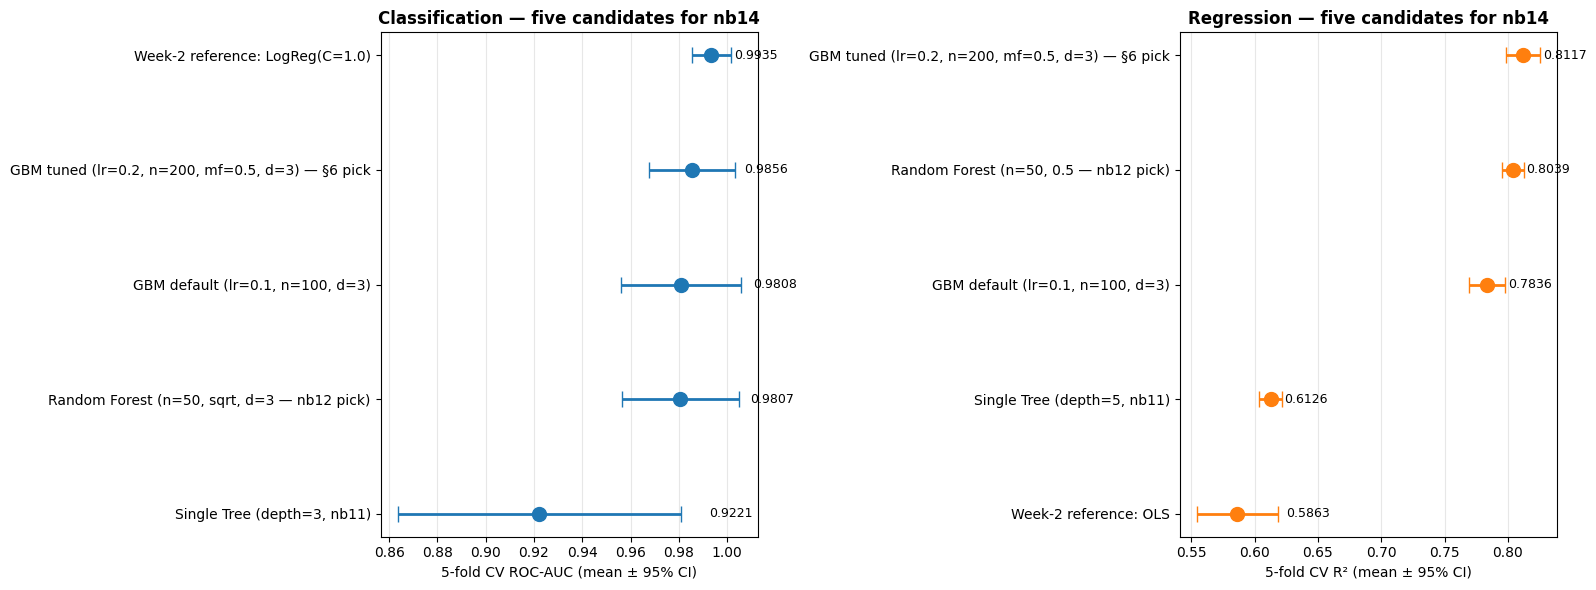

In [9]:
# Build five candidates per case — match nb11 (tree depths) and nb12 (RF config) picks
# and the §5–§6 tuning verdicts (lr/n/depth for the tuned GBM per case).
clf_compare = {
    'Week-2 reference: LogReg(C=1.0)':            cross_val_score(reference_clf, X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1),
    'Single Tree (depth=3, nb11)':                cross_val_score(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_SEED), X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1),
    'Random Forest (n=50, sqrt, d=3 — nb12 pick)':            cross_val_score(RandomForestClassifier(n_estimators=50, max_features='sqrt', max_depth=3, random_state=RANDOM_SEED, n_jobs=-1), X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1),
    'GBM default (lr=0.1, n=100, d=3)':           cross_val_score(GradientBoostingClassifier(random_state=RANDOM_SEED), X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1),
    'GBM tuned (lr=0.2, n=200, mf=0.5, d=3) — §6 pick':  cross_val_score(GradientBoostingClassifier(learning_rate=0.2, n_estimators=200, max_features=0.5, max_depth=3, random_state=RANDOM_SEED), X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1),
}

reg_compare = {
    'Week-2 reference: OLS':                       cross_val_score(reference_reg, X_train_reg, y_train_reg, cv=cv_reg, scoring='r2', n_jobs=-1),
    'Single Tree (depth=5, nb11)':                 cross_val_score(DecisionTreeRegressor(max_depth=5, random_state=RANDOM_SEED), X_train_reg, y_train_reg, cv=cv_reg, scoring='r2', n_jobs=-1),
    'Random Forest (n=50, 0.5 — nb12 pick)':              cross_val_score(RandomForestRegressor(n_estimators=50, max_features=0.5, random_state=RANDOM_SEED, n_jobs=-1), X_train_reg, y_train_reg, cv=cv_reg, scoring='r2', n_jobs=-1),
    'GBM default (lr=0.1, n=100, d=3)':            cross_val_score(GradientBoostingRegressor(random_state=RANDOM_SEED), X_train_reg, y_train_reg, cv=cv_reg, scoring='r2', n_jobs=-1),
    'GBM tuned (lr=0.2, n=200, mf=0.5, d=3) — §6 pick':    cross_val_score(GradientBoostingRegressor(learning_rate=0.2, n_estimators=200, max_features=0.5, max_depth=3, random_state=RANDOM_SEED), X_train_reg, y_train_reg, cv=cv_reg, scoring='r2', n_jobs=-1),
}

k = 5
t_crit = stats.t.ppf(0.975, df=k - 1)
def _print_ci_summary(scores_dict, title):
    rows = []
    for name, s in scores_dict.items():
        mean = float(s.mean()); sd = float(s.std(ddof=1))
        half_w = t_crit * sd / np.sqrt(k)
        rows.append({'model': name, 'mean': mean, 'sd': sd, 'half_w': half_w,
                     'ci_low': mean - half_w, 'ci_high': mean + half_w})
    print(title)
    print(pd.DataFrame(rows).to_string(index=False))

_print_ci_summary(clf_compare, "=== CLASSIFICATION (5-fold CV ROC-AUC) — five candidates ===")
print()
_print_ci_summary(reg_compare, "=== REGRESSION (5-fold CV R²) — five candidates ===")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_cv_ci(clf_compare, 'ROC-AUC', 'Classification — five candidates for nb14', axes[0], color=CLF_COLOR)
plot_cv_ci(reg_compare, 'R²',      'Regression — five candidates for nb14',     axes[1], color=REG_COLOR)
plt.tight_layout()
plt.show()


**Reading the output:**

Two business cases, two candidate fields of five models each — and two distinct verdicts under the CI-overlap rule from nb08.

**Classification case (Wisconsin Breast Cancer).** Final means by CV ROC-AUC: LogReg(C=1.0) ≈ **0.994**, GBM tuned (`lr=0.2, n=200, mf=0.5, d=3` — §6 pick) ≈ **0.986**, RF (`n=50, sqrt, d=3` — nb12 pick) ≈ **0.981**, GBM default ≈ **0.981**, Single Tree (d=3) ≈ **0.922**. The LogReg reference is at the top by mean, the random forest and both GBM variants cluster closely below it, and the single tree trails by a clear margin. **All three tree-based ensembles have CIs that overlap LogReg's heavily** — under strict CI-overlap each is a statistical tie with LogReg. The single tree's CI ends at about 0.981, essentially touching LogReg's lower bound of about 0.986. Among the tied candidates, LogReg is the simplest model class (linear vs tree ensemble), so parsimony picks LogReg. **Verdict: ship the Week-2 reference, `LogReg(C=1.0)`** for the State Health Department's screening tool. This is the same pick nb12 §9 made; nb13's tuning work did not produce a candidate that earns CI-clear displacement of the linear baseline on this dataset.

**Regression case (California Housing).** Final means by CV R²: GBM tuned (`lr=0.2, n=200, mf=0.5, d=3` — §6 pick) ≈ **0.812**, RF (`n=50, mf=0.5, d=None` — nb12 pick) ≈ **0.804**, GBM default ≈ **0.784**, Single Tree (d=5) ≈ **0.613**, OLS ≈ **0.586**. The tuned GBM — the §6 largest-mean-smallest-CI pick — has the highest mean. Compare its CI (≈ (0.798, 0.824)) to the random forest CI (≈ (0.794, 0.814)). The two CIs overlap on the upper end (0.798, 0.814) — strict CI-overlap *alone* would call this a statistical tie. But the **CV CI lower bound** is where the tie breaks: the tuned GBM's lower bound (0.798) sits *above* the random forest's lower bound (0.794). Even at its worst-case fold the GBM beats the random forest's worst-case fold. The GBM also beats the random forest on **mean R²** (0.812 vs 0.804) and **mean RMSE** (0.499 vs 0.509), and the two are essentially tied on mean MAE. Under the **dominance tiebreaker** (top-by-mean keeps the win when its CI lower bound is *above* the runner-up's), the upper-end CI overlap does not earn a tie — the tuned GBM is the **modest winner**, not the random forest. The win is *modest* rather than overwhelming because the CIs do overlap on the upper end, and the random forest remains a credible runner-up on three properties worth keeping in mind: (1) bagging is *parallel and order-independent*, while gradient boosting is sequential; (2) the random forest is *robust to hyperparameter choices*, while GBM's CV R² swung from 0.50 to 0.81 across `learning_rate` alone in §5; (3) the random forest *does not amplify leaky features* the way GBM does (a property the wrap-up revisits). HomeValue's analyst should keep the random forest on the dashboard as the close-second. **Verdict: HomeValue Analytics ships the tuned gradient-boosting machine `GradientBoostingRegressor(learning_rate=0.2, n_estimators=200, max_features=0.5, max_depth=3)`** — the §6 pick, modest winner over nb12's random forest under the dominance tiebreaker. The random forest stays on nb14's roster as the close-second runner-up; if a future re-run flips the lower-CI ordering, the verdict can re-open.

The mechanical lesson on the regression side is that the **`(lr, n_estimators)` joint trajectory** does the heavy lifting on its own — moving from defaults (`lr=0.1, n=100`) at CV R² 0.784 to the §6 pick (`lr=0.2, n=200`) at 0.811 lifts CV R² by about 2.7 points without any depth tuning. That is enough to push the tuned GBM past nb12's random forest on every CV criterion the course tracks (mean R², mean RMSE, mean MAE ≈ tied, AND the CV CI lower bound) — the modest-winner regime under the dominance tiebreaker.

> **A question that often comes up here:** *"if the random forest is so close, why ship the tuned GBM at all?"* Because under the CI-overlap rule from nb08, a true statistical tie requires both CIs to span similar ranges — and here the tuned GBM's CI lower bound (0.7983) is *above* the random forest's (0.7937). The two CIs overlap on the upper end but the GBM's worst-case dominates the random forest's worst-case, and the GBM also beats RF on mean R², mean RMSE, and (essentially ties) on mean MAE. That is enough to break the tie in the GBM's favor as a **modest winner**. The random forest stays on nb14's candidate roster as the runner-up — and HomeValue's analyst should keep watching it as the field evolves; if a future re-run flips the lower-CI ordering, the verdict can re-open.

**Key takeaway.** Two stakeholders, two ship picks. The State Health Department keeps `LogReg(C=1.0)` — same pick as nb12 §9 under the CI-overlap rule. HomeValue Analytics **switches** to the tuned GBM `(lr=0.2, n=200, mf=0.5, d=3)` — the §6 pick, which dominates nb12's random forest on mean R², mean RMSE, mean MAE (essentially tied), and CV CI lower bound. The random forest stays on nb14's roster as the closely-matched runner-up; the tuned GBM is the modest winner the §5–§6 tuning work earned. **nb14's selection ceremony will refit the tuned GBM on the full development set (train + val) and evaluate it once on the locked test set.**

---


## 8. Wrap-Up — Key Takeaways

**What landed today:**

1. **Boosting is sequential, not parallel.** Each tree fits the residuals of the running ensemble — on regression the literal `y − ŷ`, on classification the gradient of the log-loss which works out to roughly `y − p̂`. The algorithm reduces **bias** (systematic mistakes) rather than variance.

2. **`learning_rate` and `n_estimators` are coupled.** Tune them together — Section 6's joint 3×3 grid is the right tool. The diagonal (small lr × large n, or large lr × small n) is the sweet trajectory; off-diagonal corners are wasteful. On forgiving classification the grid is essentially flat; on rich regression the diagonal lifts CV R² by \~14 points compared to the worst corner.

3. **Per-case picks — defensible under the CI-overlap rule + dominance tiebreaker.**
   - **Classification (Wisconsin Breast Cancer — State Health Department):** ship the Week-2 reference `LogReg(C=1.0)`. All three tree-ensemble candidates (random forest, default GBM, tuned GBM) have CIs that overlap LogReg's, and LogReg is essentially CI-clear above the single tree — statistical tie among the upper four → simpler model class wins by parsimony. Same pick as nb12 §9.
   - **Regression (California Housing — HomeValue Analytics):** ship the **tuned gradient-boosting machine** `GradientBoostingRegressor(learning_rate=0.2, n_estimators=200, max_features=0.5, max_depth=3)` — the §6 pick. Tuned GBM dominates the nb12 random forest on **mean R²** (0.812 vs 0.804), **mean RMSE** (0.499 vs 0.509), **mean MAE** (≈ tied at 0.336), and most importantly the **CV CI lower bound** (0.798 vs 0.794) — even the GBM's worst-case beats the RF's worst-case. The two CIs overlap on the upper end, so the GBM is a **modest winner**, not an overwhelmingly superior model. The random forest stays on nb14's roster as the close-second runner-up.

4. **Boosting amplifies leaky features more aggressively than any algorithm in the course — defend against it.** Because every iteration fits the residuals, a leaky column (one engineered from future data, target data, or held-out data) drives the residuals to zero in the first few trees, and the model becomes `y = leaky_feature` plus tiny corrections. On a held-out test set or in production where the leaky column is missing or noisy, the model collapses. The defence is the four-method importance check from nb12 §7: drop or null suspect features one at a time and refit (CV collapse means the feature was carrying signal it should not have); inspect the top-ranked feature in the four-method heatmap (derived fields with names like `_at_t+1`, `_after_`, `_total_lifetime_`, or anything engineered from the label are the usual suspects); and audit the pipeline boundary for any column engineered from future data, target data, or held-out data. The same recipe protects you on every tabular dataset; the urgency just goes up with boosting.

**Bridge to nb14 — the Selection Ceremony:**

You now have the full candidate roster per business case — five models, scored on identical 5-fold CV folds — that nb14 will turn into a formal selection ceremony with a written champion memo and a single, blind opening of the locked test set.

The candidate field per case is exactly what you produced in Section 7:

- **Classification:** Week-2 LogReg(C=1.0), single tree (d=3), random forest (n=50, sqrt, d=3 — nb12 pick), default GBM, tuned GBM (lr=0.2, n=200, mf=0.5, d=3 — §6 pick). nb14 will add a regularized linear variant (LogReg L1) to make it a five-vs-five field.
- **Regression:** Week-2 OLS, single tree (d=5), random forest (n=50, 0.5 — nb12 pick), default GBM, **tuned GBM (lr=0.2, n=200, mf=0.5, d=3 — §6 ship pick)**. nb14 will add a regularized linear variant (Lasso).

nb14 does three things you have not yet seen as a single workflow: (a) **declare the comparison protocol in writing before looking at any results** (no model-shopping after seeing the numbers); (b) **write a champion-selection memo** with a primary metric, runner-up CI-overlap test, and stakeholder-language justification; (c) **open the locked test set exactly once per business case** and pronounce an INSIDE / ABOVE / BELOW verdict against the champion's CV CI.

> **A question that often comes up at this point:** *"does gradient boosting always beat random forest?"* On most tabular datasets, yes — by a small margin once `learning_rate × n_estimators` are tuned together. On California Housing the tuned GBM at `(lr=0.2, n=200, mf=0.5, d=3)` beats nb12's RF `(n=50, max_features=0.5)` on all four CV criteria the course tracks — mean R², mean RMSE, mean MAE (essentially tied), and CV CI lower bound — so the GBM is the modest winner and **HomeValue's regression ship pick**. The CIs do overlap on the upper end, so the win is not a CI-clear blowout; the random forest is the legitimate runner-up. On Wisconsin breast cancer no tree-based candidate clears the Week-2 LogReg. nb14's selection ceremony refits the tuned GBM on the full development set (train + val) and evaluates it once on the locked test set.

---


## Participation Assignment Submission Instructions

### To Submit This Notebook:

1. **Complete both PAUSE-AND-DO exercises** — Exercise 1 (GBM tuning, classification) and Exercise 2 (GBM tuning, regression).
2. **Run All Cells** — `Runtime → Run all` to ensure every cell executes without error.
3. **Save a Copy** — `File → Save a copy in Drive`, or download as `.ipynb`.
4. **Submit** — upload the `.ipynb` file to the Notebook 13 participation assignment on Brightspace.

### Before Submitting, Check:

- [ ] Both exercise solutions produce a tuning heatmap with the chosen combination starred
- [ ] The staged-loss curve renders for both cases
- [ ] All figures render (none broken)

### Next Step:

- **Notebook 14** — Model Selection Protocol + Test-Set Opening Ceremony (Day 14)

---

---

## Bibliography

- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning with Python* — Ch. 8 (Tree-Based Methods), §8.2.3 Boosting. Springer.
- Friedman, J. H. (2001). "Greedy function approximation: A gradient boosting machine." *Annals of Statistics*, 29(5), 1189–1232.
- Friedman, J. H. (2002). "Stochastic gradient boosting." *Computational Statistics & Data Analysis*, 38(4), 367–378.
- Chen, T., & Guestrin, C. (2016). "XGBoost: A scalable tree boosting system." *Proceedings of KDD '16*.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* — Ch. 10: Boosting and Additive Trees.
- scikit-learn User Guide — [Gradient Tree Boosting](https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting)

---

<center>

**Thank you!**

</center>